In [6]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, metrics
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.naive_bayes import GaussianNB
import pickle
from os import listdir
from pathlib import Path
import random as rng
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [2]:
def load_data(directory, population, var_of_interest):
    neural_act = []
    stim_id = []
    for f in listdir('./neural_activity/Scale1/' + directory + population + var_of_interest):
        neural_act.append(np.genfromtxt('./neural_activity/Scale1/' + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act)
    return neural_act, stim_id

In [3]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [4]:
def build_rdm_set(size, data, stim):
    rdm_data = []
    rdm_stim = []
    for i in range(size):
        rdm_idx = rng.randint(0, len(data)-1)
        rdm_data.append(data[rdm_idx])
        rdm_stim.append(stim[rdm_idx])
    
    return rdm_data, rdm_stim

# Amplitude

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

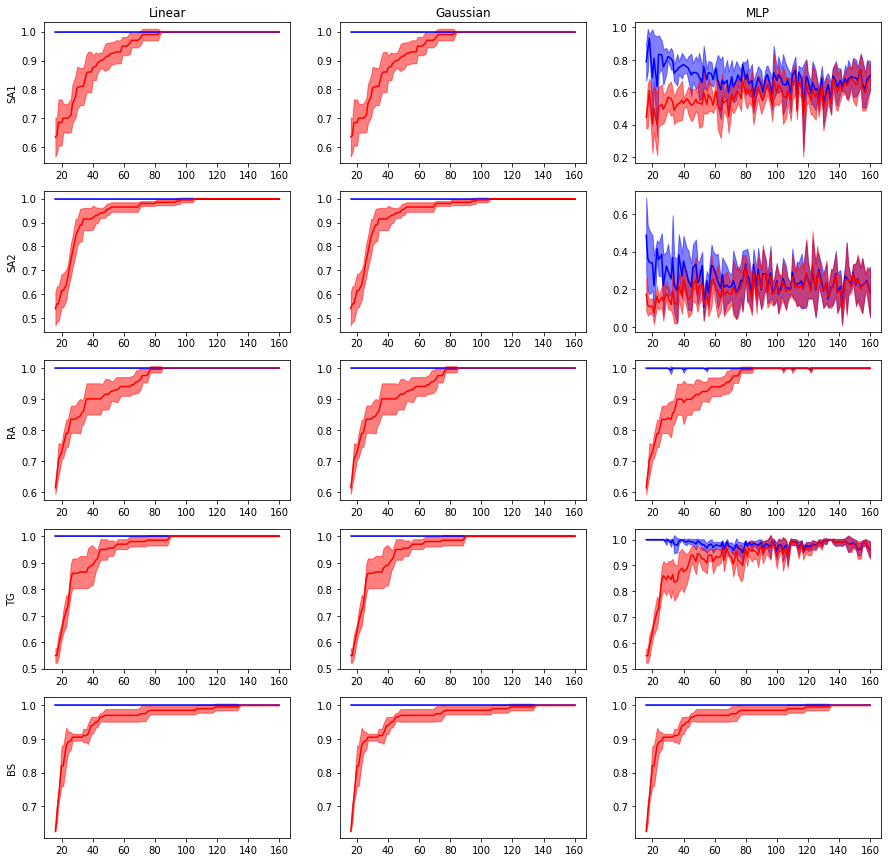

In [ ]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_amplitude', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    decoder_data, decoder_label = build_rdm_set(200, spike_per_neuron_per_stimulus, stim_id)

    
    X = decoder_data
    y = decoder_label

    clf = linear_model.RidgeClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
    axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)
    
    gnb = GaussianNB()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
    axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    mlp = MLPClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
    axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

#plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
#plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
#plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
#plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

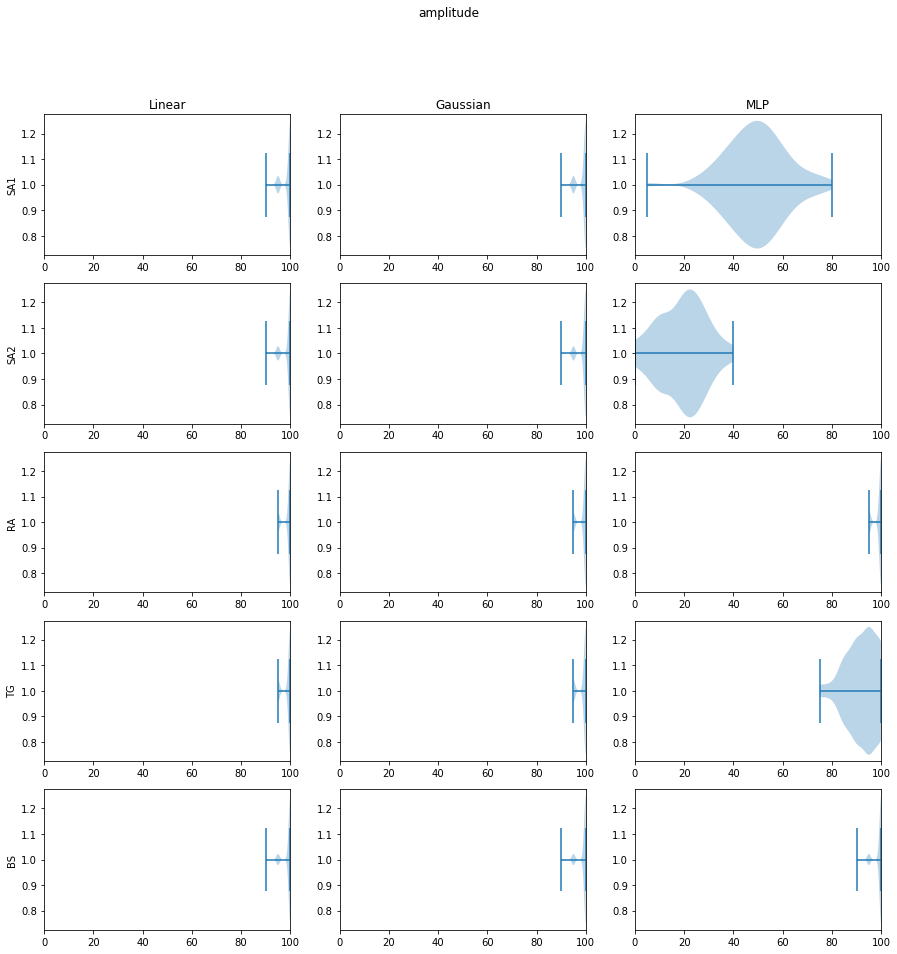

In [12]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('amplitude')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_amplitude', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 0].set_xlim([0, 100])
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 1].set_xlim([0, 100])
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    axes[j, 2].set_xlim([0, 100])
    plt.savefig('./Figures/Decoding/amplitude_full.svg')

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

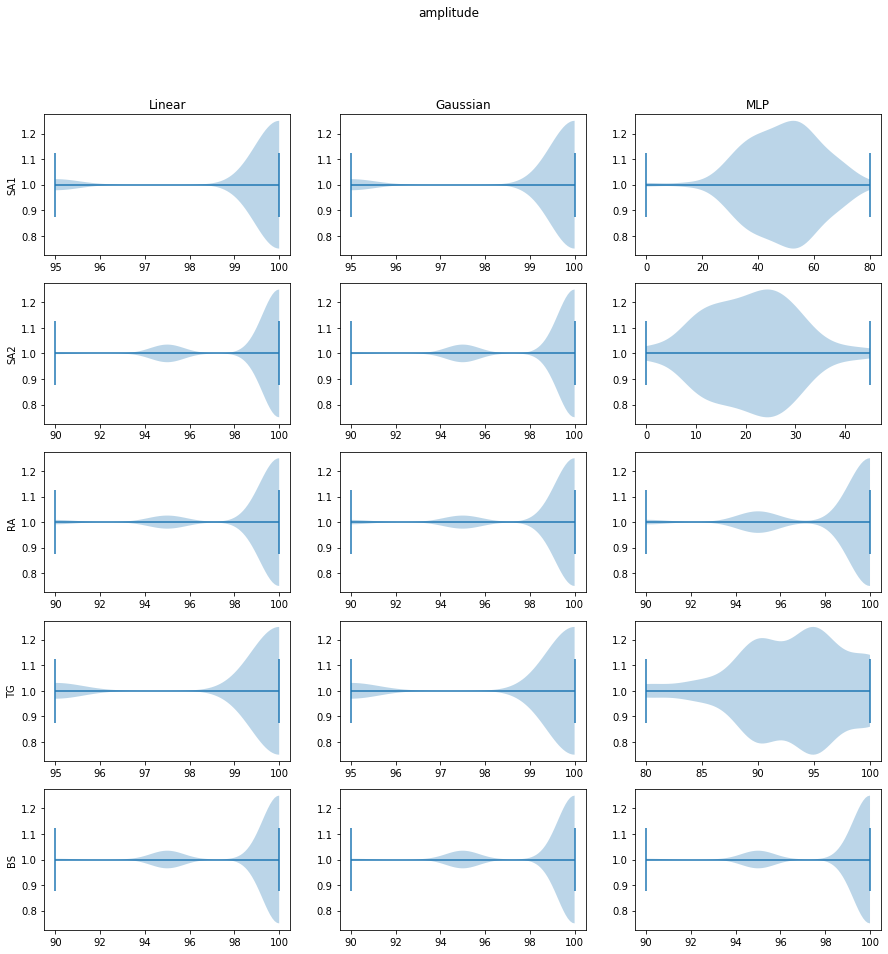

In [13]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('amplitude')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_amplitude', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    plt.savefig('./Figures/Decoding/amplitude_inset.svg')

# Direction

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\model_selection\_split.py:666: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\model_selection\_split.py:666: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"
 [py.warn

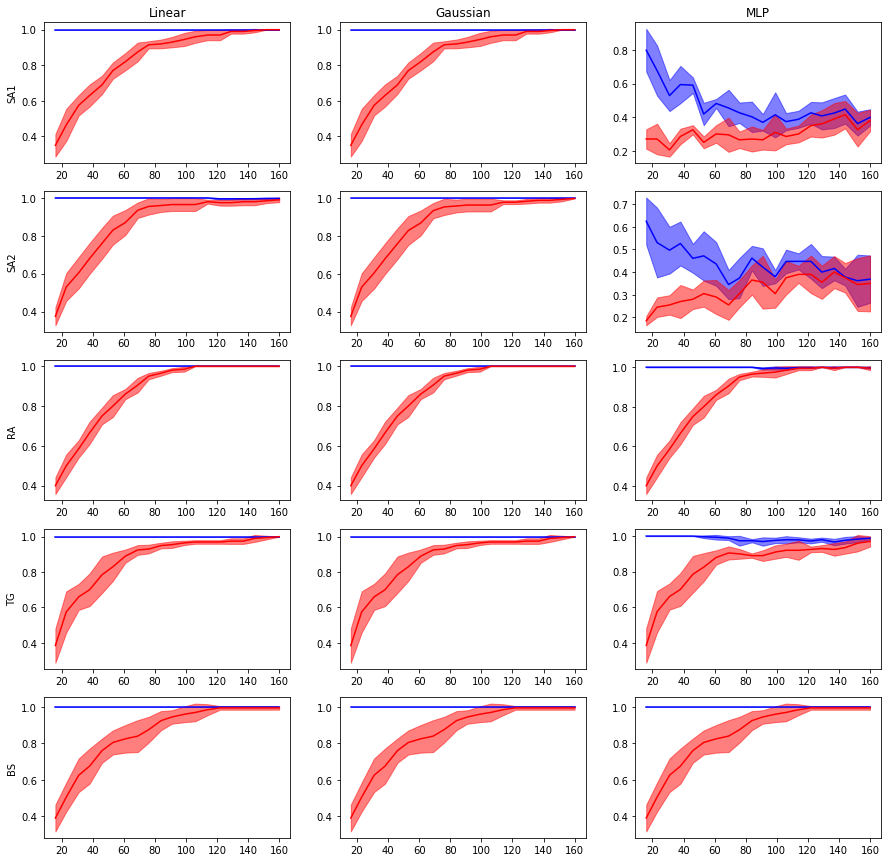

In [97]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    decoder_data, decoder_label = build_rdm_set(200, spike_per_neuron_per_stimulus, stim_id)

    axes[j, 0].set_ylabel(Populations[j])
    
    X = decoder_data
    y = decoder_label

    clf = linear_model.RidgeClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    gnb = GaussianNB()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    mlp = MLPClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

#plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
#plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
#plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
#plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

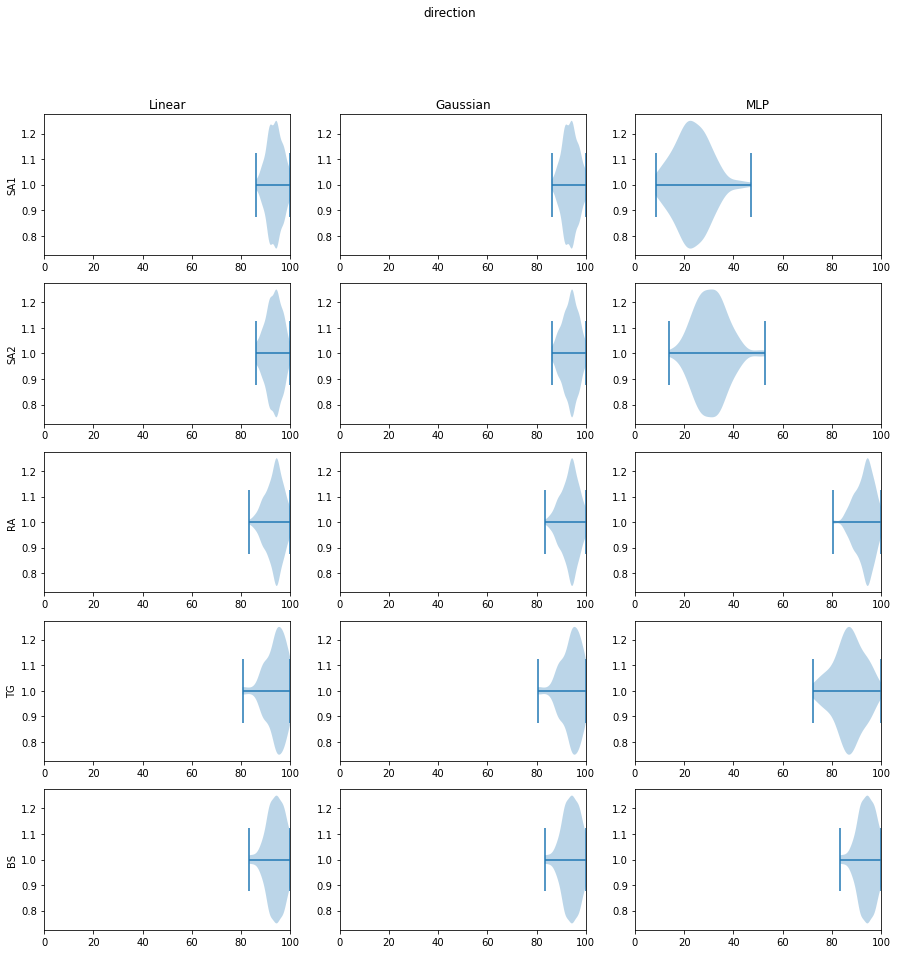

In [14]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('direction')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 0].set_xlim([0, 100])
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 1].set_xlim([0, 100])
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    axes[j, 2].set_xlim([0, 100])
    plt.savefig('./Figures/Decoding/direction_full.svg')

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

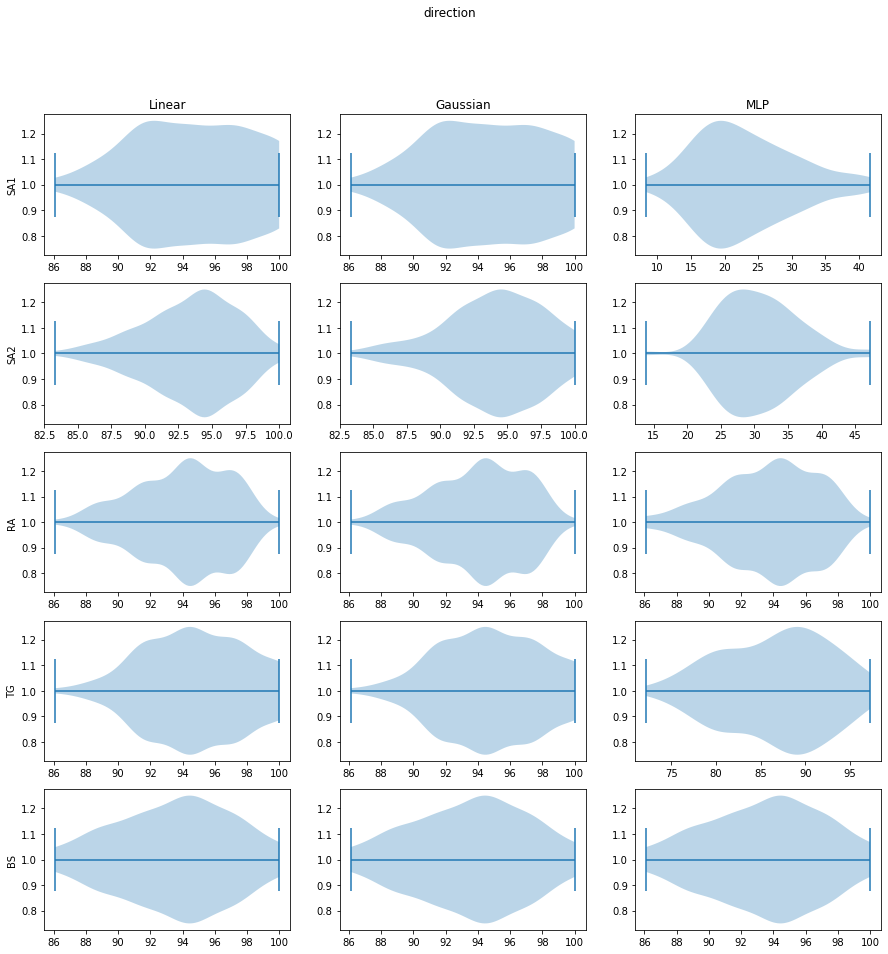

In [18]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('direction')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    plt.savefig('./Figures/Decoding/direction_inset.svg')

# Distance to basis

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\model_selection\_split.py:666: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\model_selection\_split.py:666: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"
 [py.warn

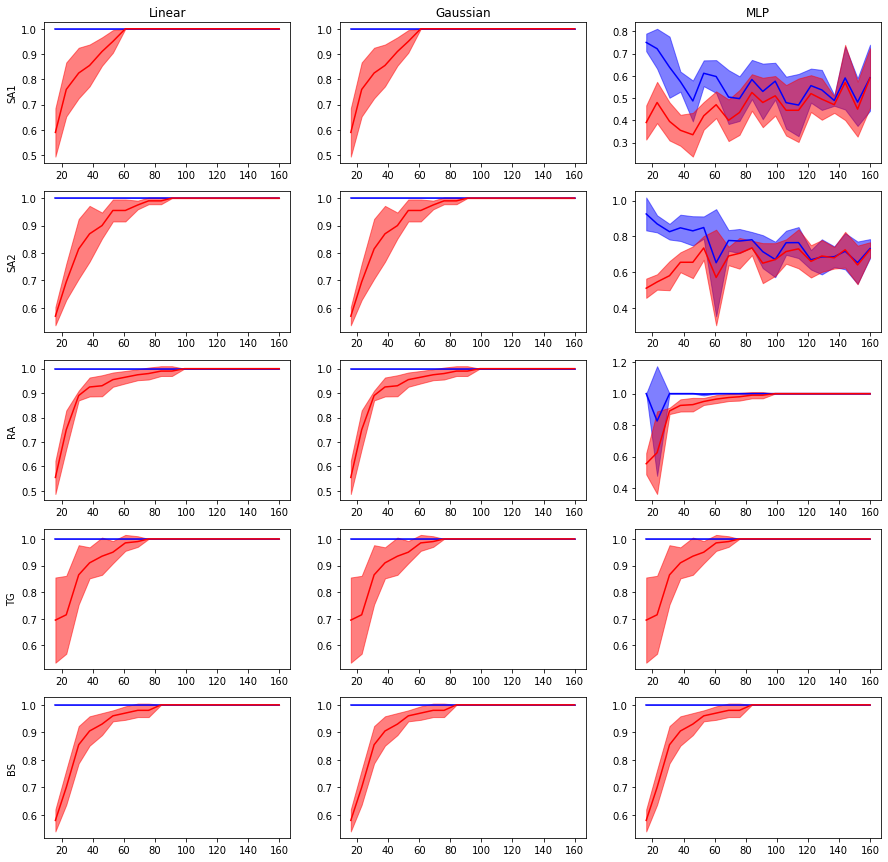

In [98]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    decoder_data, decoder_label = build_rdm_set(200, spike_per_neuron_per_stimulus, stim_id)

    axes[j, 0].set_ylabel(Populations[j])
    
    X = decoder_data
    y = decoder_label

    clf = linear_model.RidgeClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    gnb = GaussianNB()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    mlp = MLPClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

#plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
#plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
#plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
#plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

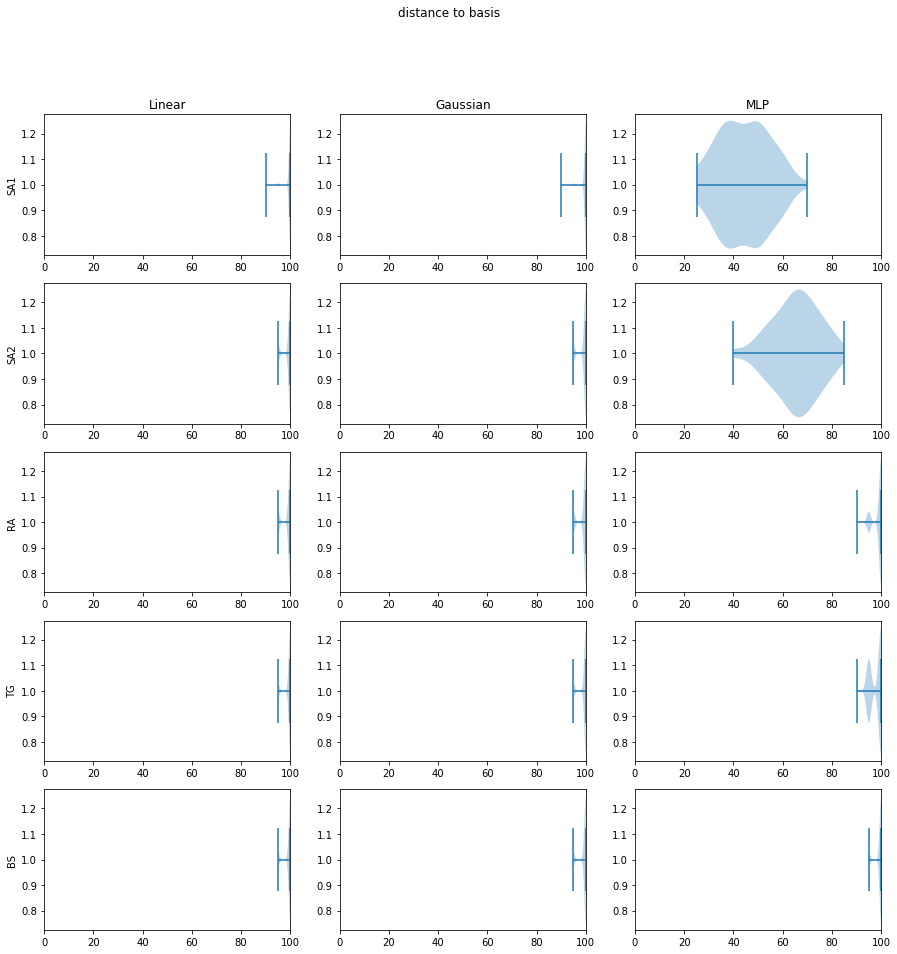

In [15]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('distance to basis')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 0].set_xlim([0, 100])
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 1].set_xlim([0, 100])
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    axes[j, 2].set_xlim([0, 100])
    plt.savefig('./Figures/Decoding/distance_to_basis_full.svg')

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

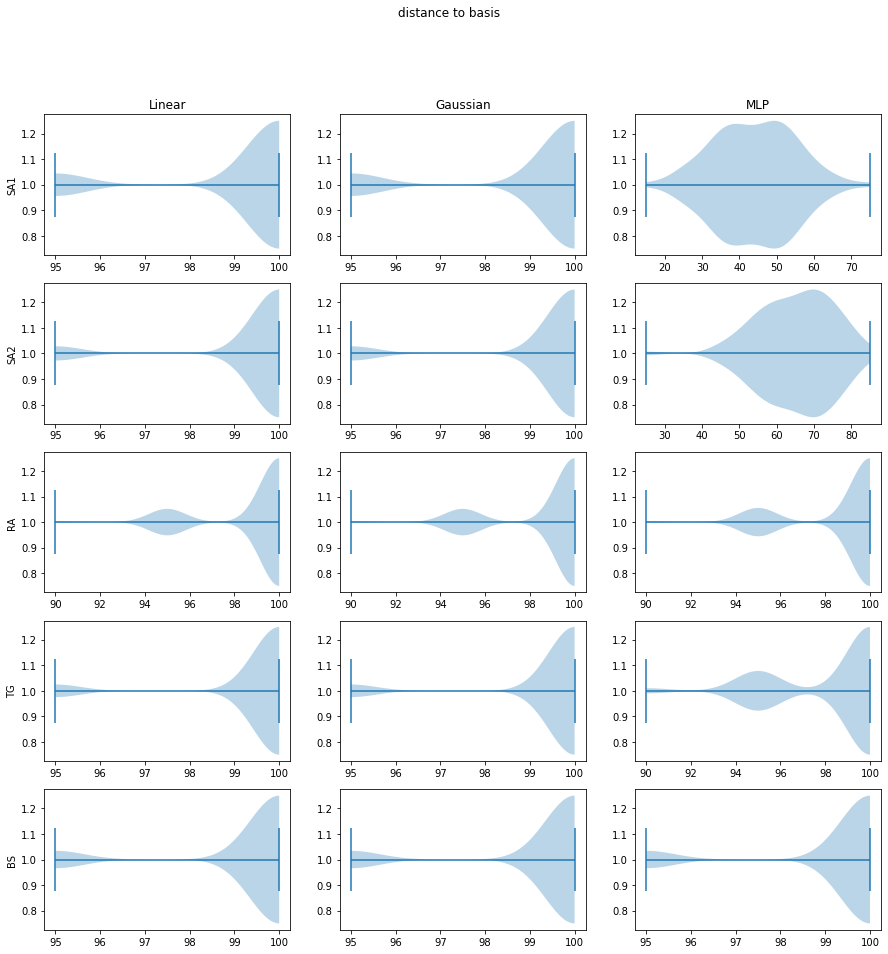

In [19]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('distance to basis')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    plt.savefig('./Figures/Decoding/distance_to_basis_inset.svg')

# Frequency

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

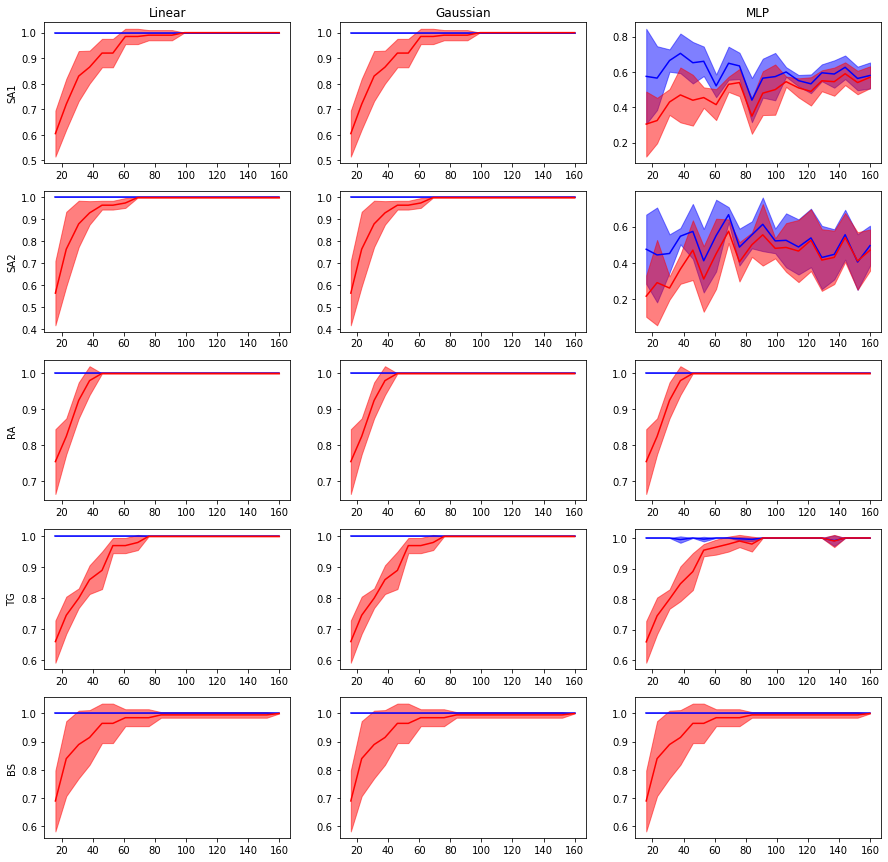

In [99]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    decoder_data, decoder_label = build_rdm_set(200, spike_per_neuron_per_stimulus, stim_id)

    axes[j, 0].set_ylabel(Populations[j])
    
    X = decoder_data
    y = decoder_label

    clf = linear_model.RidgeClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    gnb = GaussianNB()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    mlp = MLPClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

#plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
#plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
#plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
#plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

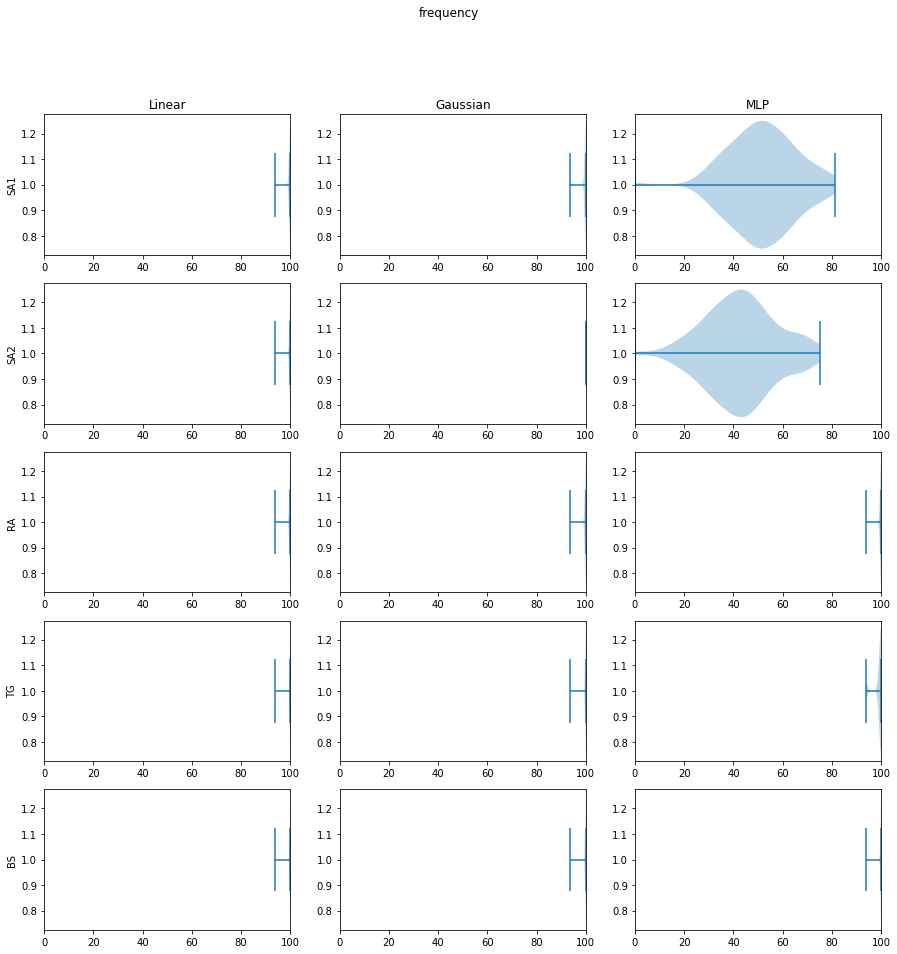

In [16]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('frequency')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 0].set_xlim([0, 100])
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 1].set_xlim([0, 100])
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    axes[j, 2].set_xlim([0, 100])
    plt.savefig('./Figures/Decoding/frequency_full.svg')

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

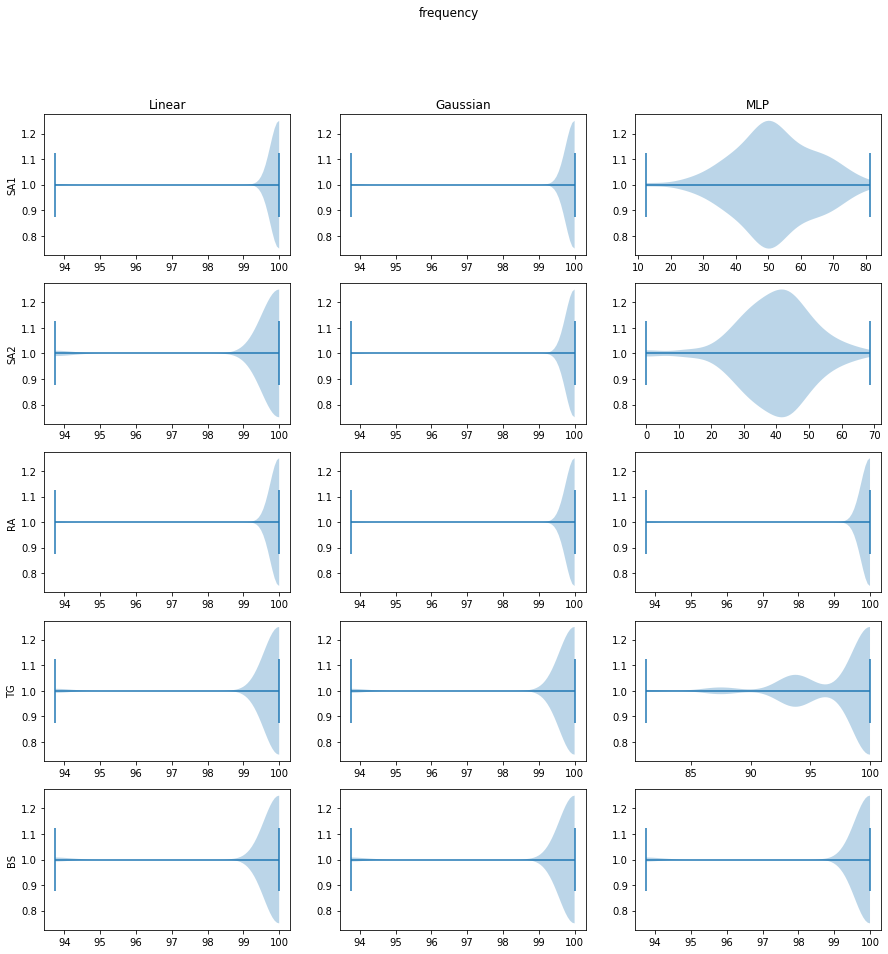

In [20]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('frequency')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    plt.savefig('./Figures/Decoding/frequency_inset.svg')

# Slope speed

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

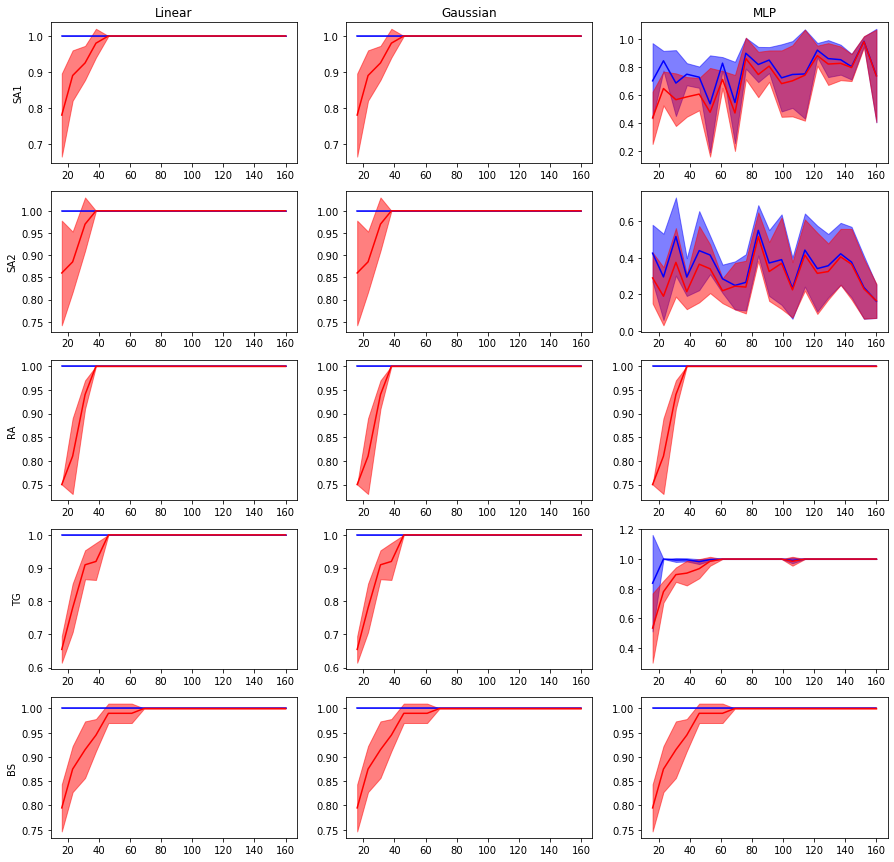

In [100]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    decoder_data, decoder_label = build_rdm_set(200, spike_per_neuron_per_stimulus, stim_id)

    axes[j, 0].set_ylabel(Populations[j])
    
    X = decoder_data
    y = decoder_label

    clf = linear_model.RidgeClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    gnb = GaussianNB()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    mlp = MLPClassifier()
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 20), return_times=True)
    axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

#plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
#plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
#plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
#plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

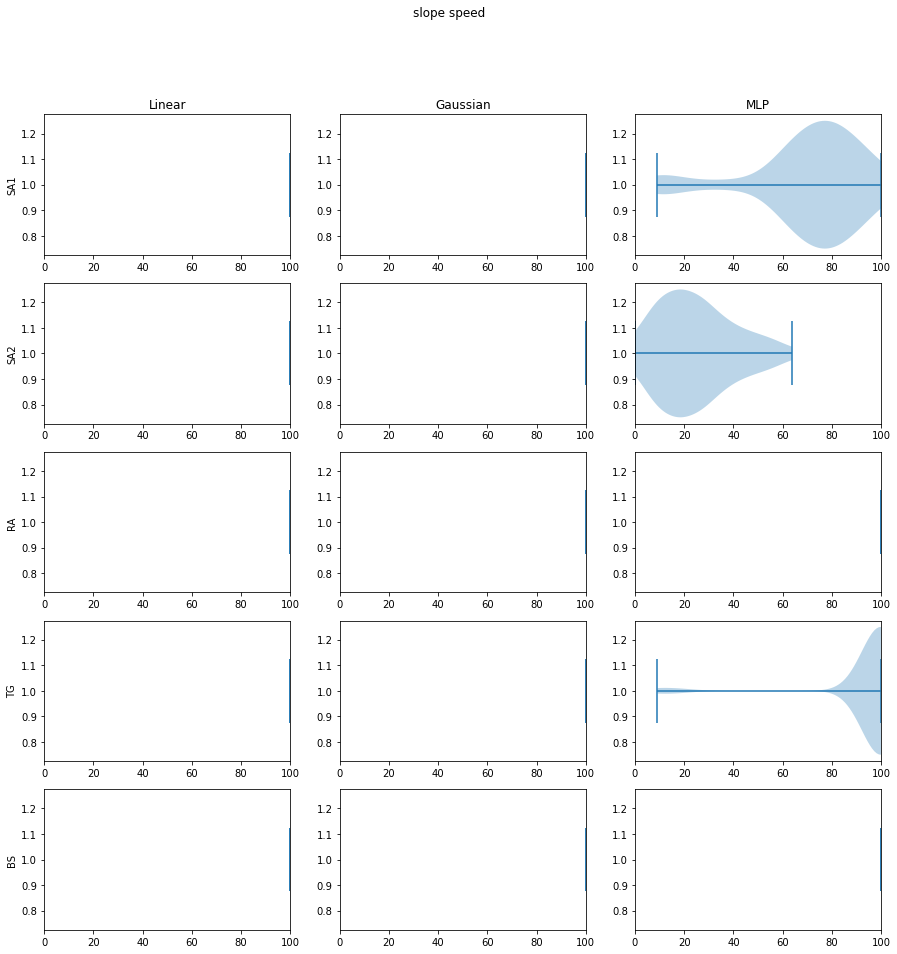

In [17]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('slope speed')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 0].set_xlim([0, 100])
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 1].set_xlim([0, 100])
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    axes[j, 2].set_xlim([0, 100])
    plt.savefig('./Figures/Decoding/slope_speed_full.svg')

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING 

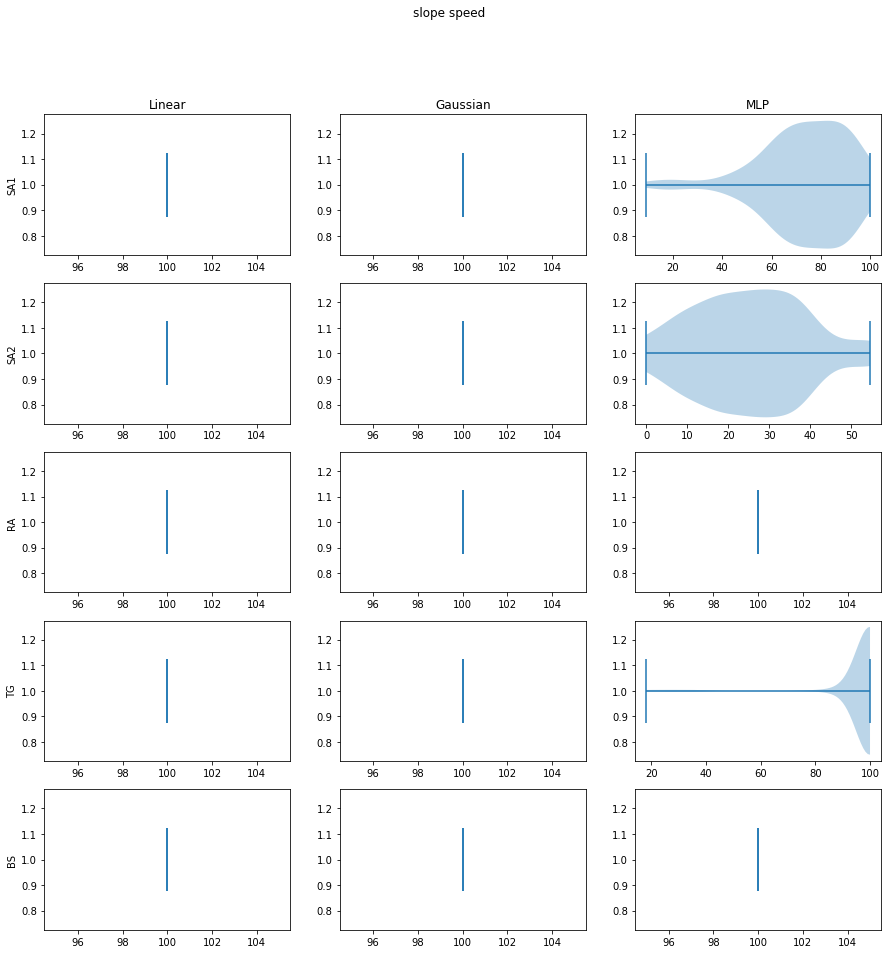

In [21]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('slope speed')
axes[0, 0].set_title('Linear')
axes[0, 1].set_title('Gaussian')

axes[0, 2].set_title('MLP')

for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

    axes[j, 0].set_ylabel(Populations[j])

    linear_score = []
    gnb_score = []
    mlp_score = []
    for w in range(100):
        decoder_data, decoder_label = build_rdm_set(100, spike_per_neuron_per_stimulus, stim_id)

        
        X = np.asarray(decoder_data)
        y = np.asarray(decoder_label, dtype=int)

        clf = linear_model.RidgeClassifier()
        clf.fit(X, y)

        gnb = GaussianNB()
        gnb.fit(X, y)

        mlp = MLPClassifier()
        mlp.fit(X, y)

        linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
    axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
    axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
    axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
    plt.savefig('./Figures/Decoding/slope_speed_inset.svg')